# Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Import the dataset
file_dir = "/content/drive/MyDrive/TUGAS AKHIR/airlines_flights_data.csv.xls" # Sesuaikan!
df = pd.read_csv(file_dir)
# Read Dataset
display(df)

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [4]:
df = pd.read_csv(url)

df.head()

NameError: name 'url' is not defined

## OVERVIEW DATA

In [5]:
df.head(2)
df.tail(2)

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [ ]:
df.shape

(300153, 12)

In [ ]:
df.dropna()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


# Cleaning Data

In [6]:
#DUPLICATE
df.duplicated().sum()

np.int64(0)

In [7]:
#missing value
df.isnull().sum()

,0
index,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [8]:
df.shape

(300153, 12)

In [9]:
df.groupby('stops')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
stops,,,,,,,,
one,250863.0,22900.992482,23626.066584,1105.0,5136.0,7959.0,48851.0,123071.0
two_or_more,13286.0,14113.450775,17664.332033,1966.0,6432.0,8307.0,13419.0,117307.0
zero,36004.0,9375.938535,10623.008293,1105.0,2586.0,4499.0,8064.0,59573.0


In [10]:
df['days_left'].describe()

,days_left
count,300153.000000
mean,26.004751
std,13.561004
min,1.000000
25%,15.000000
50%,26.000000
75%,38.000000
max,49.000000


In [11]:
df['class'].value_counts()

,count
class,
Economy,206666
Business,93487


In [12]:
df[df['price'] <= 0]
df[df['days_left'] < 0]

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


In [13]:
df['stops'].unique()
df['class'].unique()

array(['Economy', 'Business'], dtype=object)

In [16]:
def sanity_check(df):
    print("Missing values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nPrice stats:\n", df['price'].describe())
    print("\nDays_left stats:\n", df['days_left'].describe())
    print("\nUnique stops:", df['stops'].unique())
    print("\nUnique class:", df['class'].unique())

sanity_check(df)

Missing values:
 index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Duplicates: 0

Price stats:
 count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

Days_left stats:
 count    300153.000000
mean         26.004751
std          13.561004
min           1.000000
25%          15.000000
50%          26.000000
75%          38.000000
max          49.000000
Name: days_left, dtype: float64

Unique stops: ['zero' 'one' 'two_or_more']

Unique class: ['Economy' 'Business']


# Statistika Deskriptif

In [15]:
df.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [ ]:
# DROP kolom
# ↓
# SPLIT X & y
# ↓
# TRAIN-TEST SPLIT
# ↓
# MAPPING (class, stops, time)
# ↓
# ONE HOT (airline, city)
# ↓
# # ALIGN train-test

#Drop Column & Split Feature dan Target

In [17]:
#Drop Column
df = df.drop(columns=['index', 'flight'])

In [18]:
X = df.drop('price', axis=1)
y = df['price']

# Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing

Mapping Manual

In [20]:
#CLASS
X_train['class'] = X_train['class'].map({'Economy': 0, 'Business': 1})
X_test['class'] = X_test['class'].map({'Economy': 0, 'Business': 1})

In [21]:
#STOPS
X_train['stops'].unique()

array(['one', 'two_or_more', 'zero'], dtype=object)

In [22]:
#STOPS
stops_mapping = {
    'zero': 0,
    'one': 1,
    'two_or_more': 2
}

X_train['stops'] = X_train['stops'].map(stops_mapping)
X_test['stops'] = X_test['stops'].map(stops_mapping)

In [23]:
X_train['departure_time'].unique()

array(['Afternoon', 'Night', 'Morning', 'Early_Morning', 'Evening',
       'Late_Night'], dtype=object)

In [24]:
#departure_time & arrival_time
time_mapping = {
    'Early_Morning': 0,
    'Morning': 1,
    'Afternoon': 2,
    'Evening': 3,
    'Night': 4,
    'Late_Night': 5
}

X_train['departure_time'] = X_train['departure_time'].map(time_mapping)
X_test['departure_time'] = X_test['departure_time'].map(time_mapping)

X_train['arrival_time'] = X_train['arrival_time'].map(time_mapping)
X_test['arrival_time'] = X_test['arrival_time'].map(time_mapping)

ONE HOT ENCODING

In [25]:
X_train = pd.get_dummies(
    X_train,
    columns=['airline', 'source_city', 'destination_city']
)

X_test = pd.get_dummies(
    X_test,
    columns=['airline', 'source_city', 'destination_city']
)

SAMAKAN KOLOM TRAIN TEST

In [26]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [ ]:
import joblib

joblib.dump(X_train.columns, '/content/drive/MyDrive/TUGAS AKHIR/columns.pkl')

['/content/drive/MyDrive/TUGAS AKHIR/columns.pkl']

In [27]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240122 entries, 148417 to 121958
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   departure_time              240122 non-null  int64  
 1   stops                       240122 non-null  int64  
 2   arrival_time                240122 non-null  int64  
 3   class                       240122 non-null  int64  
 4   duration                    240122 non-null  float64
 5   days_left                   240122 non-null  int64  
 6   airline_AirAsia             240122 non-null  bool   
 7   airline_Air_India           240122 non-null  bool   
 8   airline_GO_FIRST            240122 non-null  bool   
 9   airline_Indigo              240122 non-null  bool   
 10  airline_SpiceJet            240122 non-null  bool   
 11  airline_Vistara             240122 non-null  bool   
 12  source_city_Bangalore       240122 non-null  bool   
 13  source_city_Ch

SCALLING FOR LINEAR REG

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# tentukan kolom numerik yang mau di-scale
num_cols = ['duration', 'days_left']

# copy data (biar aman)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# scaling
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## EDA

### 1. Distribusi Harga Tiket (Price)

> ### a. Histogram

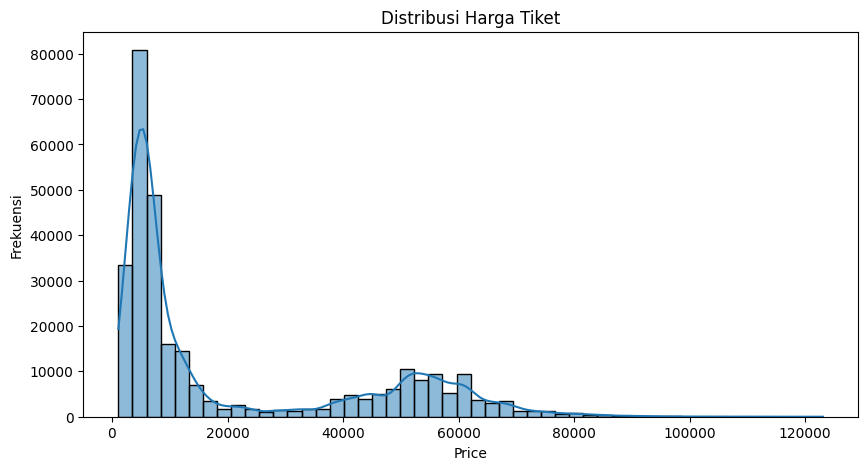

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribusi Harga Tiket')
plt.xlabel('Price')
plt.ylabel('Frekuensi')
plt.show()

> ### b. Boxplot

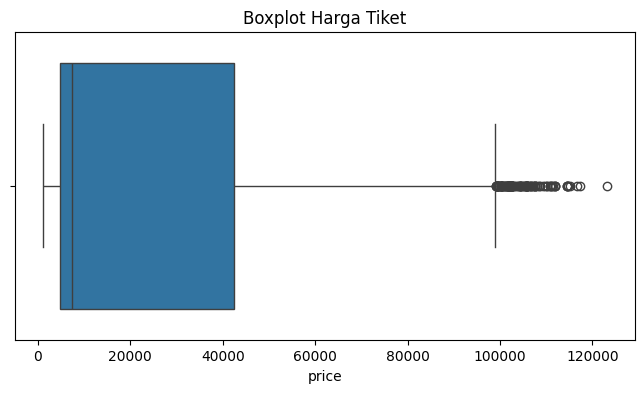

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title('Boxplot Harga Tiket')
plt.show()

> #### Distribusi harga tiket menunjukkan pola positively skewed (miring ke kanan), di mana sebagian besar data terkonsentrasi pada harga rendah hingga menengah, sementara terdapat sejumlah kecil tiket dengan harga sangat tinggi.

> #### Perbedaan signifikan antara mean dan median mengindikasikan bahwa nilai rata-rata terdorong oleh keberadaan harga ekstrem (outlier).

### 2. Statistik Deskriptif

In [ ]:
mean_price = df['price'].mean()
median_price = df['price'].median()
min_price = df['price'].min()
max_price = df['price'].max()

print("Statistik Harga Tiket:")
print(f"Mean   : {mean_price}")
print(f"Median : {median_price}")
print(f"Min    : {min_price}")
print(f"Max    : {max_price}")

Statistik Harga Tiket:
Mean   : 20889.660523133203
Median : 7425.0
Min    : 1105
Max    : 123071


> #### Nilai mean yang jauh lebih tinggi dibanding median menunjukkan adanya distribusi yang tidak simetris.

> #### Rentang harga yang sangat luas (min hingga max) mengindikasikan bahwa harga tiket sangat bervariasi, kemungkinan dipengaruhi oleh faktor seperti kelas penerbangan, rute, dan waktu pemesanan.

### 3. Outlier

> ### Grouping rute dan kelas
> ### a. Buat kolom rute

In [ ]:
df['route'] = df['source_city'] + " → " + df['destination_city']

> ### b. Grouping statistik harga

In [ ]:
group_route_class = df.groupby(['route', 'class'])['price'].agg([
    'mean', 'median', 'min', 'max', 'count'
]).reset_index()

group_route_class.sort_values(by='mean', ascending=False).head(10)

,route,class,mean,median,min,max,count
6,Bangalore → Kolkata,Business,58854.693091,60508.0,25000,105168,3141
40,Kolkata → Bangalore,Business,58681.104437,60978.0,25470,105638,2930
8,Bangalore → Mumbai,Business,58024.618208,56058.0,20760,103819,4196
50,Mumbai → Bangalore,Business,57970.544389,54608.0,20684,114523,4179
48,Kolkata → Mumbai,Business,57422.551724,58111.0,31838,110936,3364
58,Mumbai → Kolkata,Business,57106.526385,57565.0,31292,100909,3828
16,Chennai → Kolkata,Business,57078.895872,55377.0,20000,104624,2132
42,Kolkata → Chennai,Business,56502.775035,55983.0,20606,95183,2147
26,Delhi → Kolkata,Business,56239.853659,57405.0,27976,117307,3280
18,Chennai → Mumbai,Business,56223.838086,56273.0,23424,114704,3051


> #### Analisis berdasarkan rute dan kelas menunjukkan bahwa:


> #### Kelas Business secara konsisten memiliki median dan rentang harga yang lebih tinggi dibanding Economy
> #### Variasi harga dalam satu rute cukup besar, terlihat dari lebar boxplot, yang menunjukkan adanya faktor tambahan seperti waktu keberangkatan, durasi, dan jumlah transit

> #### * **Harga tiket berbeda signifikan antar rute, yang mengindikasikan adanya pengaruh jarak, permintaan, dan popularitas rute**
> #### * **Kelas Business secara konsisten memiliki median dan rentang harga yang lebih tinggi dibanding Economy**
> #### * **Variasi harga dalam satu rute cukup besar, terlihat dari lebar boxplot, yang menunjukkan adanya faktor tambahan seperti waktu keberangkatan, durasi, dan jumlah transit**

> #### Hal ini menunjukkan bahwa harga tiket tidak hanya dipengaruhi oleh satu faktor, melainkan kombinasi beberapa variabel.

> ### c. Visualisasi distribusi (Top 5 rute)

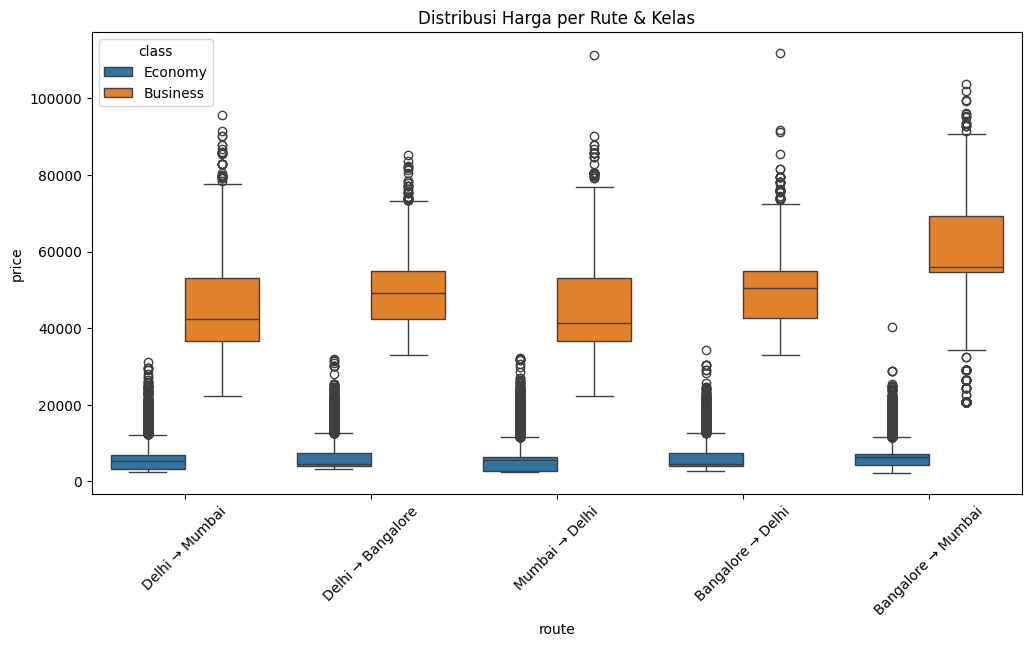

In [ ]:
top_routes = df['route'].value_counts().head(5).index
df_top = df[df['route'].isin(top_routes)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='route', y='price', hue='class')
plt.title('Distribusi Harga per Rute & Kelas')
plt.xticks(rotation=45)
plt.show()

> #### Boxplot menunjukkan adanya banyak titik di luar whisker, yang menandakan keberadaan outlier dalam jumlah signifikan.
> #### Selain itu, perbedaan median antar kelas terlihat jelas, yang menguatkan bahwa kelas penerbangan merupakan faktor utama dalam penentuan harga.

> ### d. Deteksi Outlier (Metode IQR)

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

df_outlier = df[(df['price'] < lower) | (df['price'] > upper)]
print("Jumlah outlier:", len(df_outlier))

Lower Bound: -51824.0
Upper Bound: 99128.0
Jumlah outlier: 123


> #### Deteksi outlier menggunakan metode IQR menunjukkan adanya sejumlah data dengan harga jauh di atas batas normal.

> #### Outlier ini kemungkinan berasal dari:

> #### * **Tiket kelas premium (Business/First Class)**
> #### * **Pemesanan mendekati waktu keberangkatan**
> #### * **Rute tertentu dengan permintaan tinggi**

> #### Keberadaan outlier ini dapat mempengaruhi performa model, terutama model linear, sehingga diperlukan strategi penanganan yang tepat.

> ### e. Ambil Data Outlier

In [ ]:
df_clean = df[(df['price'] >= lower) & (df['price'] <= upper)]

print("Data sebelum:", df.shape)
print("Data sesudah:", df_clean.shape)

Data sebelum: (300153, 11)
Data sesudah: (300030, 11)


> ### f. Visualisasi Outlier (Highlight)

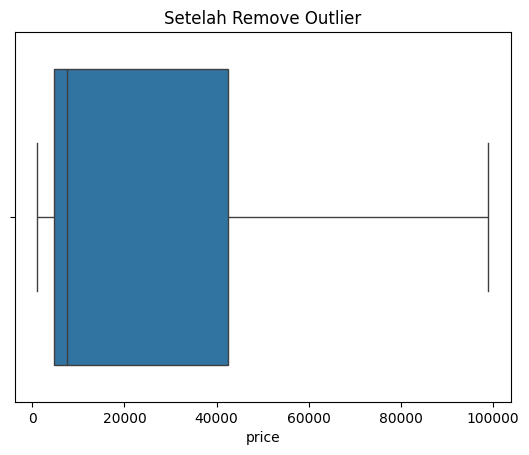

In [ ]:
sns.boxplot(x=df_clean['price'])
plt.title("Setelah Remove Outlier")
plt.show()

> #### Setelah dilakukan penanganan outlier, distribusi harga menjadi lebih stabil dan tidak terlalu ekstrem.

> ### Secara keseluruhan, hasil EDA menunjukkan bahwa harga tiket pesawat memiliki distribusi yang tidak normal dan dipengaruhi oleh berbagai faktor seperti rute, kelas penerbangan, dan karakteristik perjalanan.

> ### Keberadaan outlier dan kompleksitas hubungan antar variabel menjadi alasan penggunaan model machine learning yang mampu menangkap pola non-linear.

### 4. Distribusi Duration

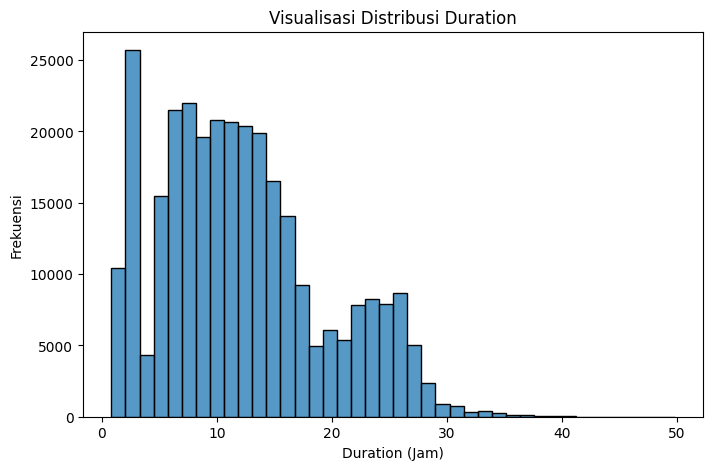

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['duration'], bins=40)

plt.title('Visualisasi Distribusi Duration')
plt.xlabel('Duration (Jam)')
plt.ylabel('Frekuensi')

plt.show()

> ### Distribusi Duration dengan menggunakan Histogram cenderung right-skewed, menunjukkan sebagian besar penerbangan berdurasi pendek–menengah.

### 5. Distribusi Days_Left

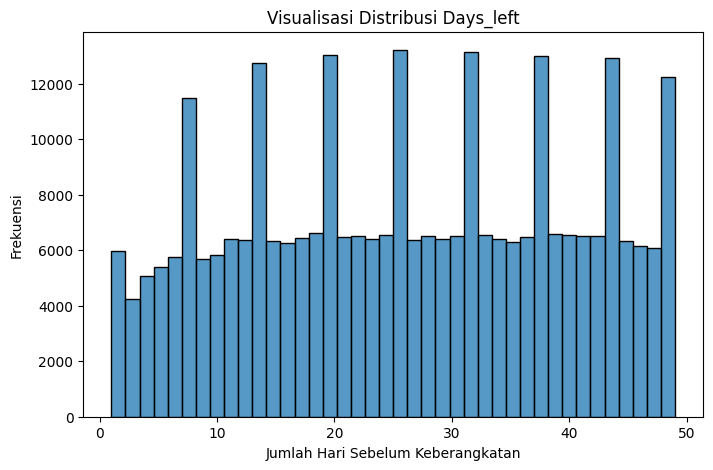

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['days_left'], bins=40)

plt.title('Visualisasi Distribusi Days_left')
plt.xlabel('Jumlah Hari Sebelum Keberangkatan')
plt.ylabel('Frekuensi')

plt.show()

> ### Sebagian besar tiket dipesan dalam rentang beberapa hari hingga beberapa minggu sebelum keberangkatan.

### 6. Proporsi di Setiap Class (economy vs business)

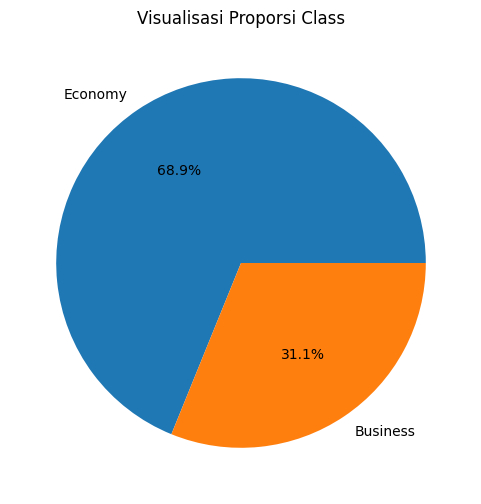

class
Economy     206666
Business     93487
Name: count, dtype: int64


In [ ]:
class_counts = df['class'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(class_counts,
        labels=class_counts.index,
        autopct='%1.1f%%')

plt.title('Visualisasi Proporsi Class')

plt.show()

print(class_counts)

> ### Kelas economy mendominasi dibanding business class.

### 7. Proporsi tiap Stops



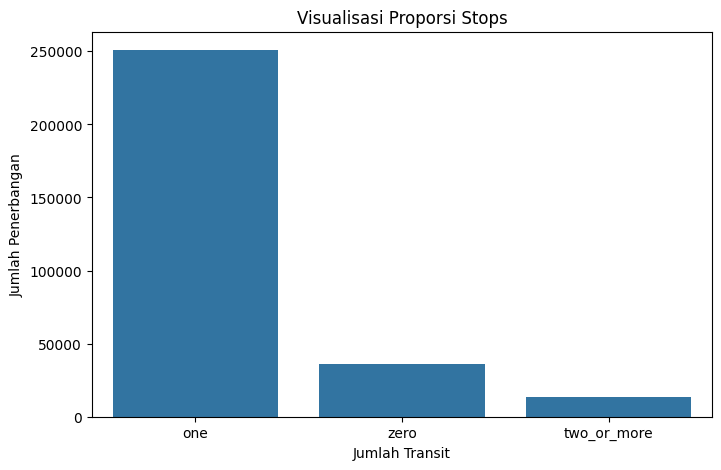

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64


In [ ]:
stops_counts = df['stops'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=stops_counts.index, y=stops_counts.values)

plt.title('Visualisasi Proporsi Stops')
plt.xlabel('Jumlah Transit')
plt.ylabel('Jumlah Penerbangan')

plt.show()

print(stops_counts)

> ### Mayoritas penerbangan memiliki 0–1 transit, menunjukkan preferensi rute yang lebih efisien.

8. Apakah class mempengaruhi harga? (Economy vs Business)
🔍 Cara Analisis

In [ ]:
df.groupby('class')['price'].mean()

,price
class,
Business,52540.081124
Economy,6572.342383


<Axes: xlabel='class', ylabel='price'>

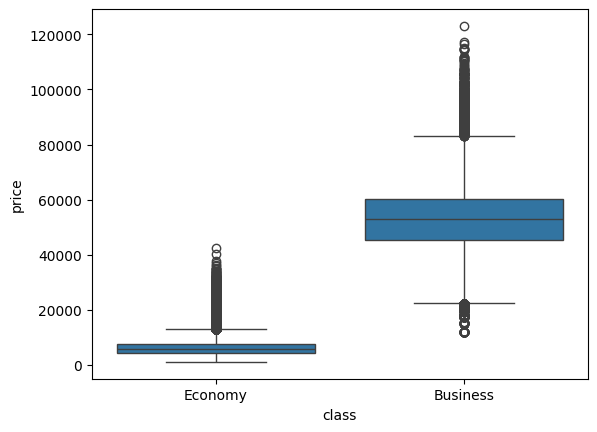

In [ ]:
sns.boxplot(x='class', y='price', data=df)

1. Rata-rata Harga

Dari output dihasilkan:

1.Business ≈ 52.540
2.Economy ≈ 6.572

Artinya:

1.Tiket Business ~8x lebih mahal dari Economy
2.Perbedaan kelas sangat signifikan terhadap harga

2. Analisis Boxplot
a. Economy
1.Median rendah (sekitar 5–7 ribu)
2.Sebaran relatif sempit
3.Banyak outlier ke atas (hingga ~40 ribu)

b. Insight yang di dapatkan:

1.Harga Economy umumnya stabil & murah
2.Tapi ada beberapa penerbangan mahal (mungkin premium economy / waktu tertentu).

c. Business
1. Median jauh lebih tinggi (~50–55 ribu)
2. Sebaran lebih lebar (variansi besar)
3. Banyak outlier tinggi (hingga >120 ribu)
4. Ada juga outlier rendah (~15–20 ribu)

d. Insight yang di dapatkan:

1. Harga Business sangat variatif
2. Dipengaruhi faktor lain (maskapai, waktu, fasilitas, dll)

9. Bagaimana pengaruh days_left terhadap harga?

In [ ]:
df[['days_left', 'price']].corr()

,days_left,price
days_left,1.000000,-0.091949
price,-0.091949,1.000000


<Axes: xlabel='days_left', ylabel='price'>

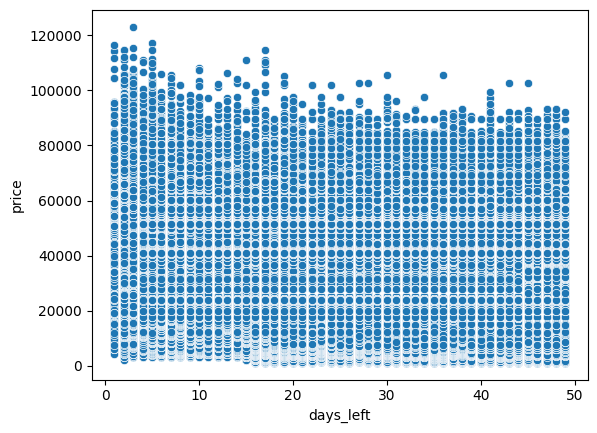

In [ ]:
sns.scatterplot(x='days_left', y='price', data=df)

1. Hasil Korelasi

Dari output yang didapatkan:

Correlation ≈ -0.0919

Artinya:

Hubungan negatif sangat lemah
Secara umum:
makin dekat hari keberangkatan → harga sedikit naik
tapi efeknya hampir tidak signifikan

2. Analisis Scatter Plot

Dari grafik:

1. Titik menyebar sangat luas (tidak membentuk pola jelas)
2. Tidak terlihat garis tren kuat
3. Harga tinggi dan rendah muncul di hampir semua nilai days_left

Insight yang didapat:

1. Tidak ada hubungan linear yang kuat
days_left bukan faktor utama penentu harga

3. Jika Interpretasi Secara Nyata

a.Biasanya secara teori:

Tiket makin dekat → makin mahal

b.Tapi di data yang digunakan:

1. Pola itu tidak terlalu terlihat kuat
2. Kemungkinan karena dipengaruhi faktor lain:
kelas (Economy vs Business) ✔️
3. maskapai
4. durasi
5. rute

10. Apakah jumlah stops mempengaruhi harga?
🔍 Cara Analisis

In [ ]:
df.groupby('stops')['price'].mean()

,price
stops,
one,22900.992482
two_or_more,14113.450775
zero,9375.938535


<Axes: xlabel='stops', ylabel='price'>

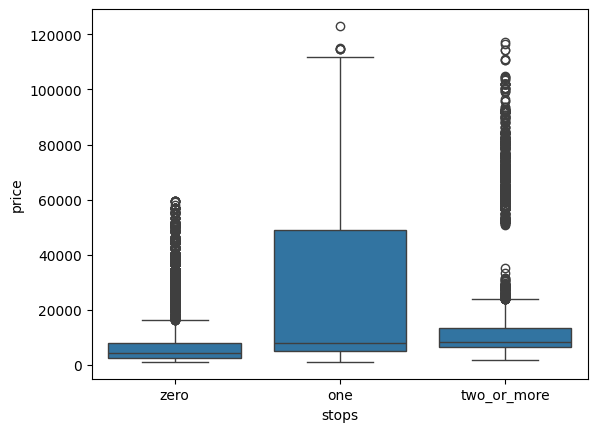

In [ ]:
sns.boxplot(x='stops', y='price', data=df)

1. Rata-rata Harga per Stops

Dari hasil:

one (1 transit) ≈ 22.900
two_or_more (≥2 transit) ≈ 14.113
zero (langsung) ≈ 9.376

Urutan harga:
1 stop > 2+ stops > non-stop

2. Analisis Boxplot

a. Zero (langsung)
1. Median paling rendah
2. Variasi kecil
3. Ada outlier tinggi (hingga ~60k)

Insight yang di dapatkan:

1. Penerbangan langsung cenderung paling murah
Harga relatif stabil

b. One (1 transit)
1. Median tinggi
2. Variasi paling besar
3. Banyak outlier ekstrem (hingga >120k)

Insight yang di dapatkan:

1. Harga paling mahal & paling tidak stabil
2. Kemungkinan:
      -transit di hub besar
      -maskapai premium

c. Two or more
1. Median di tengah
2. Variasi cukup besar
3. Banyak outlier tinggi

Insight yang didapatkan:

1. Lebih murah dari 1 stop
2. Tapi masih lebih mahal dari direct

### 11. Apakah 'duration' berpengaruh terhadap harga ('price')?

In [ ]:
#Cek kecurigaan ada outlier di kolom duration dimana mean durasi penerbangan di 12.221021, median durasi penerbangan di 11.25, tapi max durasi penerbangan di 49.83.
max_duration_mask = df['duration'] >= 40
df[max_duration_mask].sort_values(by='duration', ascending=False)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route
193889,Air_India,Chennai,Evening,two_or_more,Evening,Bangalore,Economy,49.83,2,23891,Chennai → Bangalore
194359,Air_India,Chennai,Evening,one,Evening,Bangalore,Economy,49.83,9,17538,Chennai → Bangalore
119508,Air_India,Bangalore,Evening,one,Evening,Chennai,Economy,47.75,47,7461,Bangalore → Chennai
261152,Air_India,Bangalore,Evening,one,Evening,Chennai,Business,47.75,47,55122,Bangalore → Chennai
193926,Vistara,Chennai,Morning,one,Morning,Bangalore,Economy,47.08,3,17223,Chennai → Bangalore
293606,Air_India,Chennai,Afternoon,two_or_more,Morning,Bangalore,Business,45.83,6,51928,Chennai → Bangalore
194141,Air_India,Chennai,Afternoon,two_or_more,Morning,Bangalore,Economy,45.83,6,12813,Chennai → Bangalore
194650,Air_India,Chennai,Afternoon,two_or_more,Morning,Bangalore,Economy,45.83,13,12813,Chennai → Bangalore
197808,Air_India,Chennai,Evening,one,Afternoon,Kolkata,Economy,44.50,1,32439,Chennai → Kolkata
170753,Air_India,Hyderabad,Night,one,Afternoon,Kolkata,Economy,42.00,1,33853,Hyderabad → Kolkata


Kecurigaan kita bantah dulu karena ternyata memang ada flight yang membutuhkan durasi lebih atau sama dengan 40.00, terutama flight antara Kolkata dan Mumbai.Selain itu, flight antara Chennai dan Bangalore juga membutuhkan durasi flight yang panjang >40.

<Axes: xlabel='duration', ylabel='price'>

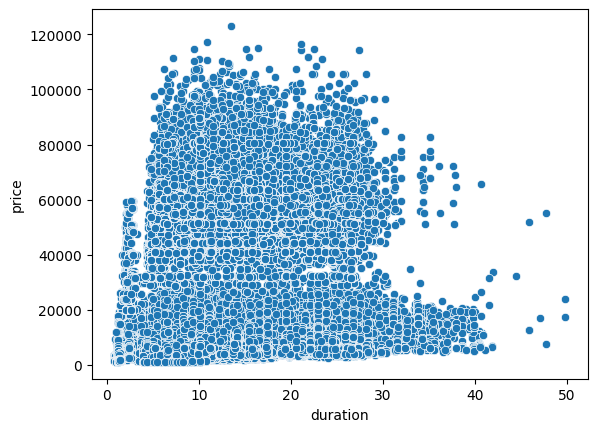

In [ ]:
#cek korelasi duration terhadap price (tanpa filter apa-apa)
#scatterplot antara duration (x-axis) dan price (y-axis)
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='duration', y='price')

In [ ]:
#cek korelasi Pearson antara duration dan price
correlation = df['duration'].corr(df['price'])
print(f"Korelasi Pearson: {correlation}")

Korelasi Pearson: 0.20422236784542702


Insights yang didapatkan:


1.   Dari scatterplot, tidak terlihat ada hubungan yang jelas antara price dan duration karena titik tersebar secara acak tanpa membentuk pola tertentu.
2.   Diperkuat dengan pengecekan korelasi Pearson dengan nilai 0.204 yang berarti tidak ada korelasi kuat antara variabel duration dengan price.


Lanjut cek korelasi duration terhadap price tapi dengan filter:


1.   airline
2.   source_city
3.   destination_city
4.   class



In [ ]:
grouped_corr = (
    df
    .groupby(['airline', 'source_city', 'destination_city', 'class'])
    .apply(lambda x: x['duration'].corr(x['price']))
    .reset_index(name='correlation')
)

print(grouped_corr.sort_values('correlation'))

       airline source_city destination_city     class  correlation
98    GO_FIRST     Chennai          Kolkata   Economy    -0.659685
223    Vistara     Kolkata        Hyderabad  Business    -0.294963
8      AirAsia     Chennai          Kolkata   Economy    -0.294485
209    Vistara   Hyderabad          Chennai  Business    -0.231509
213    Vistara   Hyderabad          Kolkata  Business    -0.191016
..         ...         ...              ...       ...          ...
54   Air_India       Delhi        Hyderabad  Business     0.686177
125     Indigo     Chennai        Bangalore   Economy     0.699198
150   SpiceJet   Bangalore          Chennai   Economy          NaN
152   SpiceJet   Bangalore        Hyderabad   Economy          NaN
165   SpiceJet   Hyderabad          Chennai   Economy          NaN

[237 rows x 5 columns]


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_37294/2639555322.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['duration'].corr(x['price']))


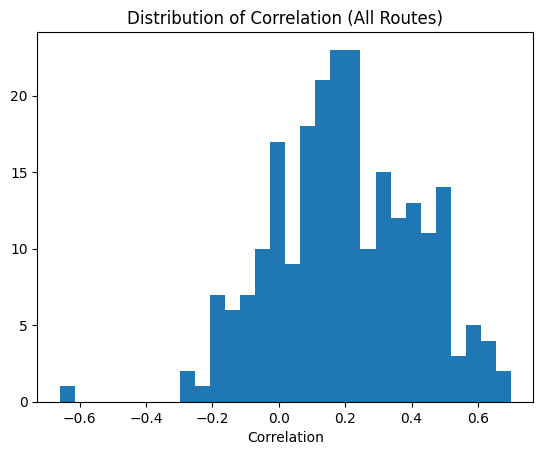

In [ ]:
plt.figure()
plt.hist(grouped_corr['correlation'], bins=30)
plt.xlabel('Correlation')
plt.title('Distribution of Correlation (All Routes)')
plt.show()

Insights yang didapatkan:


1.   Mayoritas correlation pada positif lemah (0.1-0.3), berarti duration ada pengaruh terhadap price akan tetapi bukan penentu utama.
2.   Distribusi correlation sangat lebar dari -0.6 sampai 0.7, menguatkan insight no.1 dimana duration bukan jadi penentu utama terhadap pemberian price tiket pesawat.

Ada faktor lain selain duration yang perlu dianalisa yang lebih berpengaruh terhadap penentuan price.

### 12&13. Airline mana yang paling mahal dan paling murah?

In [ ]:
#cek price berdasarkan airline (tanpa filter)
summary = df.groupby('airline')['price'].agg(['min', 'max', 'mean', 'median', 'count'])

print(summary.sort_values('mean'))

            min     max          mean   median   count
airline                                               
AirAsia    1105   31917   4091.072742   3276.0   16098
Indigo     1105   31952   5324.216303   4453.0   43120
GO_FIRST   1105   32803   5652.007595   5336.0   23173
SpiceJet   1106   34158   6179.278881   5654.0    9011
Air_India  1526   90970  23507.019112  11520.0   80892
Vistara    1714  123071  30396.536302  15543.0  127859


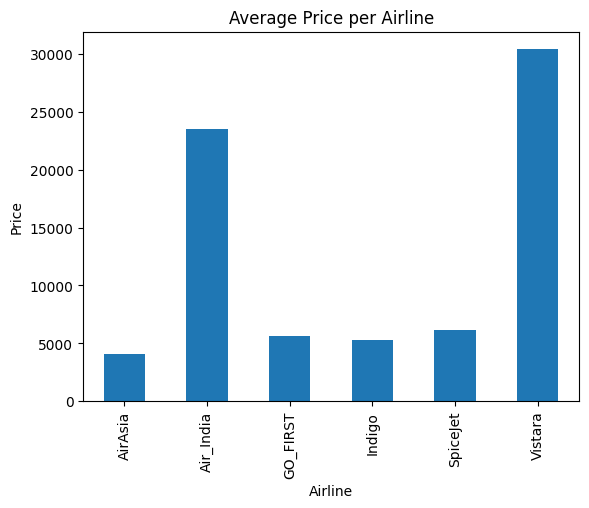

In [ ]:
#visualisasi avg_price untuk masing-masing airline
import matplotlib.pyplot as plt

summary['mean'].plot(kind='bar')

plt.title('Average Price per Airline')
plt.ylabel('Price')
plt.xlabel('Airline')
plt.show()

Insights yang didapatkan:
1. Airline Vistara punya price untuk tiket pesawat paling mahal dengan mean di 15543.
2. Airline Air Asia punya price untuk tiket pesawat paling murah dengan mean di 4091.
3. Jarak antara mean dan max price untuk masing-masing airline sangat jauh, bahkan airline yang paling murah Air Asia dengan mean price di 4091 memiliki max price di 31917.

Secara umum, terlihat jelas airline Vistara memiliki price paling mahal, sedangkan airline AirAsia paling murah. Akan tetapi, perlu dianalisa apakah ini berlaku untuk semua rute dan kelas.

In [ ]:
grouped = (
    df
    .groupby(['source_city', 'destination_city', 'class', 'airline'])['price']
    .mean()
    .reset_index()
)

In [ ]:
#penerbangan termurah untuk masing-masing rute dan kelas
idx = grouped.groupby(['source_city', 'destination_city', 'class'])['price'].idxmin()
cheapest_per_route = grouped.loc[idx]

print(cheapest_per_route)

    source_city destination_city     class    airline         price
1     Bangalore          Chennai  Business    Vistara  51001.403708
2     Bangalore          Chennai   Economy    AirAsia   2073.043478
8     Bangalore            Delhi  Business  Air_India  40608.953832
10    Bangalore            Delhi   Economy    AirAsia   4807.092426
17    Bangalore        Hyderabad  Business    Vistara  50120.350427
18    Bangalore        Hyderabad   Economy    AirAsia   2931.494792
24    Bangalore          Kolkata  Business  Air_India  55836.149203
26    Bangalore          Kolkata   Economy    AirAsia   4443.468160
32    Bangalore           Mumbai  Business  Air_India  51648.610770
34    Bangalore           Mumbai   Economy    AirAsia   3342.385350
41      Chennai        Bangalore  Business    Vistara  51684.619835
42      Chennai        Bangalore   Economy    AirAsia   1914.760870
48      Chennai            Delhi  Business  Air_India  42005.112344
50      Chennai            Delhi   Economy    Ai

In [ ]:
#penerbangan termahal untuk masing-masing rute dan kelas
idx = grouped.groupby(['source_city', 'destination_city', 'class'])['price'].idxmax()
most_exp_per_route = grouped.loc[idx]

print(most_exp_per_route)

    source_city destination_city     class    airline         price
0     Bangalore          Chennai  Business  Air_India  56301.932367
3     Bangalore          Chennai   Economy  Air_India   8219.478261
9     Bangalore            Delhi  Business    Vistara  51151.271555
14    Bangalore            Delhi   Economy   SpiceJet   6901.620408
16    Bangalore        Hyderabad  Business  Air_India  51169.902655
19    Bangalore        Hyderabad   Economy  Air_India   8107.723730
25    Bangalore          Kolkata  Business    Vistara  60025.829430
31    Bangalore          Kolkata   Economy    Vistara   9670.000949
33    Bangalore           Mumbai  Business    Vistara  61452.101869
39    Bangalore           Mumbai   Economy    Vistara   7691.231988
40      Chennai        Bangalore  Business  Air_India  56733.854749
43      Chennai        Bangalore   Economy  Air_India   8859.248373
49      Chennai            Delhi  Business    Vistara  56202.598901
55      Chennai            Delhi   Economy    Vi

Penerbangan termurah pada semua rute di Business class selalu ada pada airline Air India atau Vistara.

Muncul kecurigaan: Apakah airline lain (Air Asia, Go First, Indigo dan Spice Jet) tidak menawarkan business class?

In [ ]:
df.groupby('airline')['class'].unique()

,class
airline,
AirAsia,[Economy]
Air_India,"[Economy, Business]"
GO_FIRST,[Economy]
Indigo,[Economy]
SpiceJet,[Economy]
Vistara,"[Economy, Business]"


Dugaan benar, airline Air Asia, Go First, Indigo dan Spice Jet hanya menawarkan Economy class, dan tidak ada Business class.

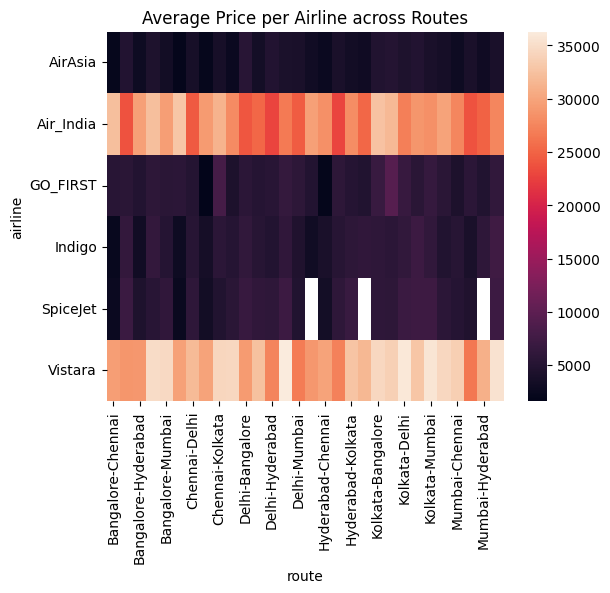

In [ ]:
#visualisasi harga rata-rata price per airline untuk masing-masing rute
import seaborn as sns

grouped = (
    df.groupby(['airline','source_city','destination_city','class'])['price']
    .mean()
    .reset_index()
)

grouped['route'] = grouped['source_city'] + '-' + grouped['destination_city']

pivot = grouped.pivot_table(
    index='airline',
    columns='route',
    values='price'
)

sns.heatmap(pivot, annot=False)
plt.title('Average Price per Airline across Routes')
plt.show()

Insights yang didapatkan:
1. Vistara dan Air India konsisten dengan pricing tinggi di semua rute.
2. Airline Air Asia, Go First, Indigo dan SpiceJet konsisten dengan pricing rendah di semua rute.
3. Airline Vistara dan Air India memiliki mean price yang tinggi karena menawarkan Business class, sedangkan airline lainnya tidak.

Hubungan antara class dengan price perlu dianalisis karena ada indikasi korelasi yang kuat.

# MODELLING

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

LINEAR REGRESSION (USING SCALED DATA)

In [30]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

LASSO

In [31]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)  # alpha = regularisasi
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

RIDGE

In [32]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

RANDOM FOREST

In [33]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

XG BOOST

In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

EVALUASI MODEL

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)  # manual
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [37]:
mae_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr)
mae_lasso, rmse_lasso, r2_lasso = evaluate_model(y_test, y_pred_lasso)
mae_ridge, rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge)
mae_rf, rmse_rf, r2_rf = evaluate_model(y_test, y_pred_rf)
mae_xgb, rmse_xgb, r2_xgb = evaluate_model(y_test, y_pred_xgb)

COMPARISON MODEL

In [38]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso', 'Ridge','Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_lasso, mae_ridge, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_lasso, rmse_ridge, rmse_rf, rmse_xgb],
    'R2 Score': [r2_lr, r2_lasso, r2_ridge, r2_rf, r2_xgb]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4499.183678,6826.223674,0.909604
1,Lasso,4497.607981,6826.208447,0.909605
2,Ridge,4499.172005,6826.222365,0.909604
3,Random Forest,1083.169948,2786.903547,0.984933
4,XGBoost,2332.430908,4108.705149,0.967251


In [39]:
results.sort_values(by='R2 Score', ascending=False)

,Model,MAE,RMSE,R2 Score
3,Random Forest,1083.169948,2786.903547,0.984933
4,XGBoost,2332.430908,4108.705149,0.967251
1,Lasso,4497.607981,6826.208447,0.909605
2,Ridge,4499.172005,6826.222365,0.909604
0,Linear Regression,4499.183678,6826.223674,0.909604


CHECK APAKAH MODEL OVERFIT?

In [40]:
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

train_score, test_score

(0.9975230970655936, 0.9849328836762693)

In [41]:
'price' not in X_train.columns

True

In [42]:
corr = pd.concat([X_train, y_train], axis=1).corr()
corr['price'].sort_values(ascending=False)

,price
price,1.000000
class,0.937802
airline_Vistara,0.359918
duration,0.203165
stops,0.119529
airline_Air_India,0.070846
departure_time,0.021166
destination_city_Kolkata,0.020948
source_city_Chennai,0.019465
destination_city_Chennai,0.018250


# feature importance plot (RANDOM FOREST)

In [43]:
import pandas as pd

# ambil importance
importance = rf.feature_importances_

# buat dataframe
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
})

# urutkan
feature_importance = feature_importance.sort_values(
    by='importance', ascending=False
)

In [44]:
top10 = feature_importance.head(10)
top10

,feature,importance
3,class,0.879856
4,duration,0.059146
5,days_left,0.018487
7,airline_Air_India,0.005000
11,airline_Vistara,0.004964
2,arrival_time,0.004058
0,departure_time,0.004052
14,source_city_Delhi,0.003791
20,destination_city_Delhi,0.003444
17,source_city_Mumbai,0.002245


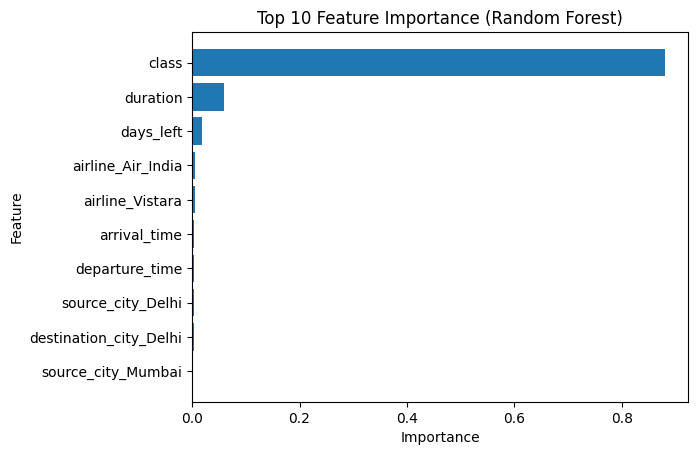

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top10['feature'], top10['importance'])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Random Forest)")

plt.show()

MENYIMPAN MODEL TERBAIK BERDASARKAN NILAI R2

In [50]:
best_model = rf  # contoh misalnya Random Forest terbaik
from sklearn.pipeline import Pipeline
import joblib

# Simpan model
pipeline = Pipeline([
    ('model', RandomForestRegressor())
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, '/content/drive/MyDrive/TUGAS AKHIR/model.pkl')

['/content/drive/MyDrive/TUGAS AKHIR/model.pkl']

In [47]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 40.4 MB/s eta 0:00:00


In [49]:
import streamlit as st
# load
model = joblib.load('/content/drive/MyDrive/TUGAS AKHIR/model.pkl')
columns = joblib.load('/content/drive/MyDrive/TUGAS AKHIR/columns.pkl')

st.title("✈️ Flight Price Prediction")

# INPUT
duration = st.number_input("Duration", min_value=0.0)
days_left = st.number_input("Days Left", min_value=0)

class_type = st.selectbox("Class", ["Economy", "Business"])
stops = st.selectbox("Stops", ["zero", "one", "two_or_more"])

departure_time = st.selectbox(
    "Departure Time",
    ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
)

arrival_time = st.selectbox(
    "Arrival Time",
    ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
)

airline = st.text_input("Airline")
source_city = st.text_input("Source City")
destination_city = st.text_input("Destination City")

# mapping
class_map = {'Economy': 0, 'Business': 1}
stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
time_map = {
    'Early_Morning': 0, 'Morning': 1, 'Afternoon': 2,
    'Evening': 3, 'Night': 4, 'Late_Night': 5
}

if st.button("Predict"):

    data = {
        'duration': duration,
        'days_left': days_left,
        'class': class_map[class_type],
        'stops': stops_map[stops],
        'departure_time': time_map[departure_time],
        'arrival_time': time_map[arrival_time]
    }

    df_input = pd.DataFrame([data])

    # ONE HOT MANUAL
    for col in columns:
        if col not in df_input.columns:
            df_input[col] = 0

    if f'airline_{airline}' in columns:
        df_input[f'airline_{airline}'] = 1

    if f'source_city_{source_city}' in columns:
        df_input[f'source_city_{source_city}'] = 1

    if f'destination_city_{destination_city}' in columns:
        df_input[f'destination_city_{destination_city}'] = 1

    df_input = df_input[columns]

    pred = model.predict(df_input)[0]

    st.success(f"💰 Harga: {pred:,.0f}")

2026-04-16 08:20:25.941 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 08:20:26.296 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-16 08:20:26.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 08:20:26.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 08:20:26.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 08:20:26.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 08:20:26.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 08:20:26.307 Thread 'MainThread': mi